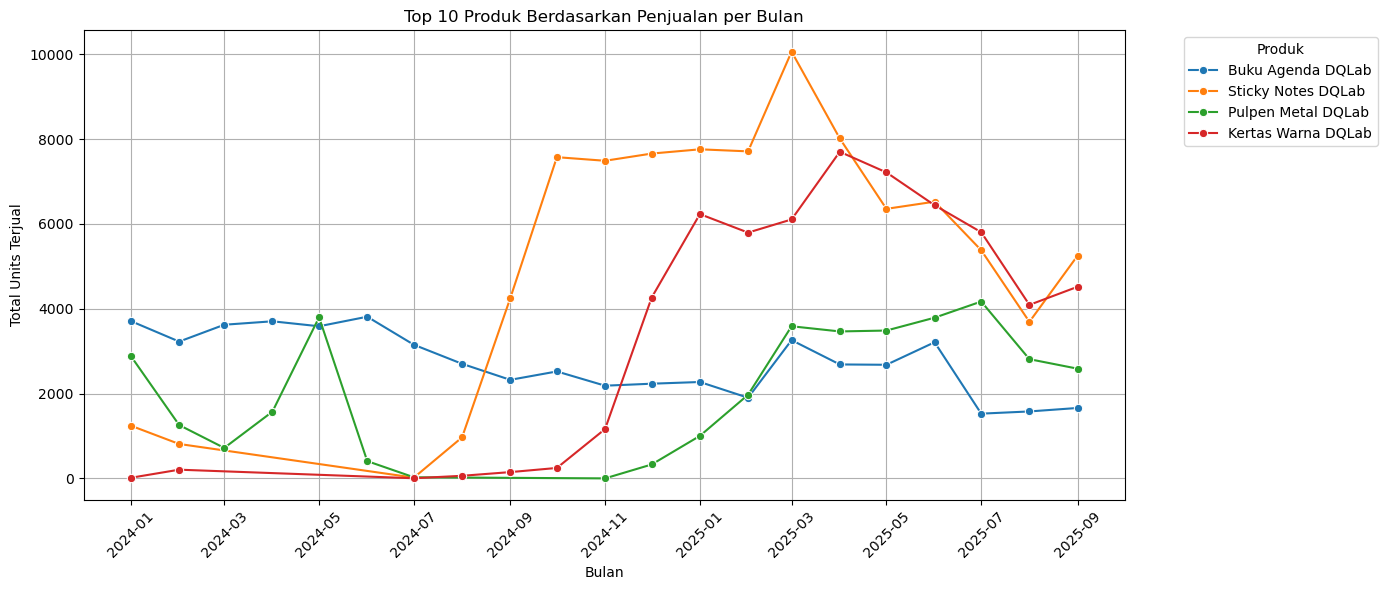

In [1]:
#membaca library
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#membaca dataset dari file csv
df_transaction = pd.read_csv('https://dqlabcdn.xeratic.com/dqlab-dataset/tbl_transaction.csv')
df_product = pd.read_csv('https://dqlabcdn.xeratic.com/dqlab-dataset/tbl_product.csv')

#menggabungkan dua dataset
df_merged = pd.merge(df_transaction, df_product, on= 'product_id', how='left')

#mengurutkan dataset yang baru sesuai ketentuan
df_merged = df_merged[['trx_id', 'trx_date', 'product_id', 'product_name', 'product_category', 'product_cost', 'product_price', 'units']]

#merubah format trx_date menjadi tanggal
df_merged['trx_date'] = pd.to_datetime(df_merged['trx_date'].astype(str), format = '%d%m%Y', errors = 'coerce')

#merubah format units menjadi integer
df_merged['units'] = df_merged['units'].fillna(0).astype(int)

#menghapus nilai yang kosong
df_merged = df_merged.dropna()

#menghapus duplikasi
df_merged = df_merged.drop_duplicates()

#membuat kolom periode (bulan)
df_merged['trx_month'] = df_merged['trx_date'].dt.to_period('M').dt.to_timestamp()

#membuat agregasi penjualan per produk per bulan
df_sales_summary = df_merged.groupby(['trx_month', 'product_id', 'product_name'])['units'].sum().reset_index()

#Hitung total units per produk (keseluruhan bulan)
top_products = df_sales_summary.groupby('product_name')['units'].sum().nlargest(5).index

#Filter df_sales_summary hanya untuk 10 produk terlaris
df_top_sales = df_sales_summary[df_sales_summary['product_name'].isin(top_products)].copy()

#Visualisasikan Data
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_top_sales, x = 'trx_month', y = 'units', hue = 'product_name', marker = 'o')
plt.title('Top 10 Produk Berdasarkan Penjualan per Bulan', fontsize=20, fontweight='bold', color='green')
plt.xlabel('Bulan', fontsize=13)
plt.ylabel('Total Units Terjual', fontsize=13)
plt.xticks(rotation = 45)
plt.legend(title = 'Produk', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.grid(True)
plt.show()